In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

import functions.eddy_feedback as ef

# 6-hourly

In [ ]:
path = '/home/links/ct715/data_storage/reanalysis/jra55_daily/processed_efp'

path_6h = os.path.join(path, '6h_ubar_epf-pr-QG_1MS_1958-2016.nc')
ds_6h = xr.open_dataset(path_6h)
ds_6h

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 708, level: 37, lat: 73)
Coordinates:
  * lat      (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * level    (level) float64 296B 1e+03 975.0 950.0 925.0 ... 5.0 3.0 2.0 1.0
  * time     (time) datetime64[ns] 6kB 1958-01-01 1958-02-01 ... 2016-12-01
Data variables:
    ubar     (time, level, lat) float32 8MB ...
    div1_pr  (time, level, lat) float64 15MB ...
    div1_QG  (time, level, lat) float64 15MB ...

In [17]:
path_daily = os.path.join(path, 'daily_ubar_epf-pr-QG_1MS_1958-2016.nc')
ds_daily = xr.open_dataset(path_daily)
ds_daily

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 708, level: 37, lat: 73)
Coordinates:
  * lat      (lat) float64 584B -90.0 -87.5 -85.0 -82.5 ... 82.5 85.0 87.5 90.0
  * level    (level) float64 296B 1e+03 975.0 950.0 925.0 ... 5.0 3.0 2.0 1.0
  * time     (time) datetime64[ns] 6kB 1958-01-01 1958-02-01 ... 2016-12-01
Data variables:
    ubar     (time, level, lat) float32 8MB ...
    div1_pr  (time, level, lat) float64 15MB ...
    div1_QG  (time, level, lat) float64 15MB ...

In [18]:
import pandas as pd

time_slices = [(1958, 2016), (1979, 2016), (1979, 2014)]
datasets = [
    (ds_6h, '6h'),
    (ds_daily, 'daily')
]
div1_methods = ['div1_pr', 'div1_QG']

results = []

for ds, freq in datasets:
    print(f"\n{'='*60}")
    print(f"Processing {freq} data")
    print('='*60)
    
    for div1 in div1_methods:
        print(f"\n  Method: {div1}")
        print('  ' + '-'*56)
        
        for times in time_slices:
            print(f"    Slice times: {times[0]}-{times[1]}")
            ds_times = ds.sel(time=slice(f"{times[0]}-01", f"{times[1]}-12"))
            
            # Calculate full-level EFP
            nh = ef.calculate_efp(ds_times, which_div1=div1, data_type='reanalysis', calc_south_hemis=False)
            sh = ef.calculate_efp(ds_times, which_div1=div1, data_type='reanalysis', calc_south_hemis=True)
            print(f"    Full-level: NH={nh:.4f}, SH={sh:.4f}")
            
            # Calculate 500hPa EFP
            nh_500 = ef.calculate_efp(ds_times, which_div1=div1, data_type='reanalysis', calc_south_hemis=False, slice_500hPa=True)
            sh_500 = ef.calculate_efp(ds_times, which_div1=div1, data_type='reanalysis', calc_south_hemis=True, slice_500hPa=True)
            print(f"    500hPa:     NH={nh_500:.4f}, SH={sh_500:.4f}")
            
            # Store in dictionary
            results.append({
                'time_freq': freq,
                'div1_method': div1,
                'period': f"{times[0]}-{times[1]}",
                'efp_nh': nh,
                'efp_sh': sh,
                'efp_nh_500': nh_500,
                'efp_sh_500': sh_500
            })

# Create DataFrame
df_efp = pd.DataFrame(results)
print("\n" + "="*60)
print("Final DataFrame:")
print(df_efp)


Processing 6h data

  Method: div1_pr
  --------------------------------------------------------
    Slice times: 1958-2016
    Full-level: NH=0.3849, SH=0.2914
    500hPa:     NH=0.3750, SH=0.2628
    Slice times: 1979-2016
    Full-level: NH=0.4498, SH=0.3524
    500hPa:     NH=0.4541, SH=0.3119
    Slice times: 1979-2014
    Full-level: NH=0.4525, SH=0.3500
    500hPa:     NH=0.4602, SH=0.3256

  Method: div1_QG
  --------------------------------------------------------
    Slice times: 1958-2016
    Full-level: NH=0.3532, SH=0.2740
    500hPa:     NH=0.3050, SH=0.2267
    Slice times: 1979-2016
    Full-level: NH=0.4260, SH=0.3266
    500hPa:     NH=0.3941, SH=0.2616
    Slice times: 1979-2014
    Full-level: NH=0.4294, SH=0.3207
    500hPa:     NH=0.3989, SH=0.2633

Processing daily data

  Method: div1_pr
  --------------------------------------------------------
    Slice times: 1958-2016
    Full-level: NH=0.3199, SH=0.1775
    500hPa:     NH=0.3143, SH=0.1165
    Slice times:

In [19]:
df_efp

,time_freq,div1_method,period,efp_nh,efp_sh,efp_nh_500,efp_sh_500
0,6h,div1_pr,1958-2016,0.3849,0.2914,0.3750,0.2628
1,6h,div1_pr,1979-2016,0.4498,0.3524,0.4541,0.3119
2,6h,div1_pr,1979-2014,0.4525,0.3500,0.4602,0.3256
3,6h,div1_QG,1958-2016,0.3532,0.2740,0.3050,0.2267
4,6h,div1_QG,1979-2016,0.4260,0.3266,0.3941,0.2616
5,6h,div1_QG,1979-2014,0.4294,0.3207,0.3989,0.2633
6,daily,div1_pr,1958-2016,0.3199,0.1775,0.3143,0.1165
7,daily,div1_pr,1979-2016,0.3846,0.2114,0.3927,0.1327
8,daily,div1_pr,1979-2014,0.3888,0.2070,0.4012,0.1381
9,daily,div1_QG,1958-2016,0.2885,0.1734,0.2418,0.1057


In [ ]:
# df_efp.to_csv('./data/jra55_efp_results.csv', index=False)

# Comparison without 1979-2014

In [24]:
df2 = df_efp.copy()
df2 = df2[df2['period'] != '1979-2014']
df2

,time_freq,div1_method,period,efp_nh,efp_sh,efp_nh_500,efp_sh_500
0,6h,div1_pr,1958-2016,0.3849,0.2914,0.3750,0.2628
1,6h,div1_pr,1979-2016,0.4498,0.3524,0.4541,0.3119
3,6h,div1_QG,1958-2016,0.3532,0.2740,0.3050,0.2267
4,6h,div1_QG,1979-2016,0.4260,0.3266,0.3941,0.2616
6,daily,div1_pr,1958-2016,0.3199,0.1775,0.3143,0.1165
7,daily,div1_pr,1979-2016,0.3846,0.2114,0.3927,0.1327
9,daily,div1_QG,1958-2016,0.2885,0.1734,0.2418,0.1057
10,daily,div1_QG,1979-2016,0.3613,0.2027,0.3308,0.1080


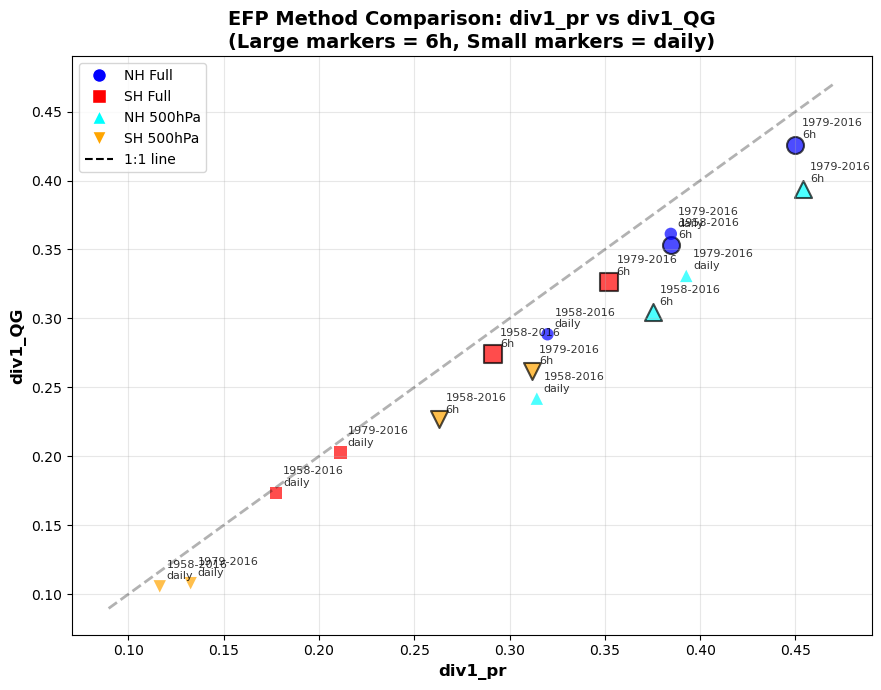

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

# Pivot to get div1_pr and div1_QG as columns
df_pivot = df2.pivot_table(values=['efp_nh', 'efp_sh', 'efp_nh_500', 'efp_sh_500'],
                               index=['period', 'time_freq'],
                               columns='div1_method').reset_index()

# Flatten column names
df_pivot.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                    for col in df_pivot.columns.values]

# Define colors and markers for different metrics
metric_styles = {
    'efp_nh': {'color': 'blue', 'marker': 'o', 'label': 'NH Full'},
    'efp_sh': {'color': 'red', 'marker': 's', 'label': 'SH Full'},
    'efp_nh_500': {'color': 'cyan', 'marker': '^', 'label': 'NH 500hPa'},
    'efp_sh_500': {'color': 'orange', 'marker': 'v', 'label': 'SH 500hPa'}
}

# Plot each metric
for metric, style in metric_styles.items():
    for idx, row in df_pivot.iterrows():
        x = row[f'{metric}_div1_pr']
        y = row[f'{metric}_div1_QG']
        
        # Different marker size for different frequencies
        size = 150 if row['time_freq'] == '6h' else 80
        edge = 'black' if row['time_freq'] == '6h' else 'none'
        
        ax.scatter(x, y, c=style['color'], marker=style['marker'], 
                  s=size, alpha=0.7, edgecolors=edge, linewidths=1.5)
        
        # Add label
        label = f"{row['period']}\n{row['time_freq']}"
        ax.annotate(label, (x, y), xytext=(5, 5), textcoords='offset points',
                   fontsize=8, alpha=0.8)

# Add 1:1 reference line
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), 
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=2, label='1:1 line')

ax.set_xlabel('div1_pr', fontsize=12, fontweight='bold')
ax.set_ylabel('div1_QG', fontsize=12, fontweight='bold')
ax.set_title('EFP Method Comparison: div1_pr vs div1_QG\n(Large markers = 6h, Small markers = daily)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker=style['marker'], color='w', 
                         markerfacecolor=style['color'], markersize=10, label=style['label'])
                  for style in metric_styles.values()]
legend_elements.append(Line2D([0], [0], color='k', linestyle='--', label='1:1 line'))
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

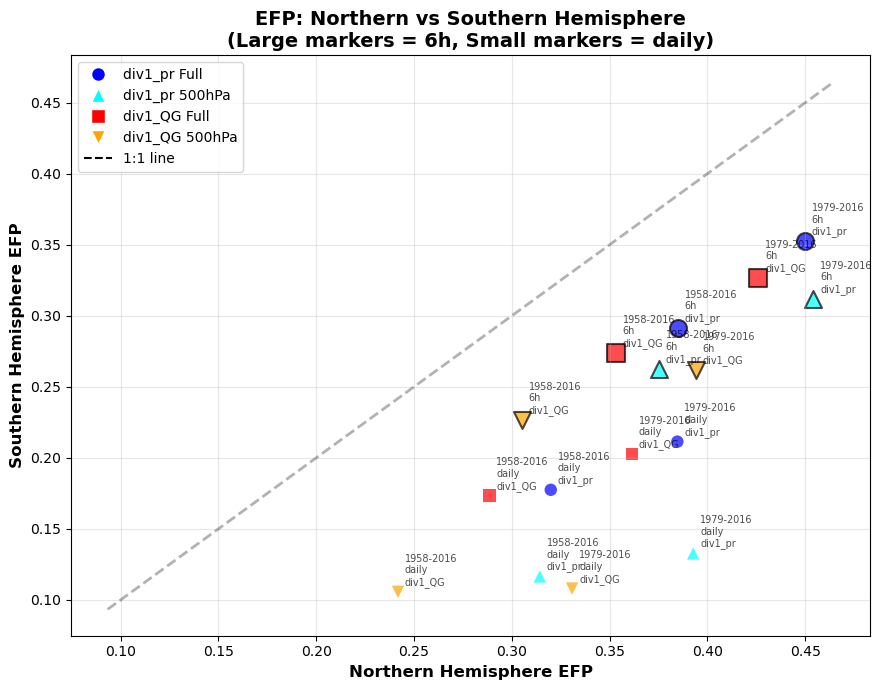

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

# Define styles for different combinations
# Colors for div1 method, markers for level
styles = {
    ('div1_pr', 'full'): {'color': 'blue', 'marker': 'o', 'label': 'div1_pr Full'},
    ('div1_pr', '500hPa'): {'color': 'cyan', 'marker': '^', 'label': 'div1_pr 500hPa'},
    ('div1_QG', 'full'): {'color': 'red', 'marker': 's', 'label': 'div1_QG Full'},
    ('div1_QG', '500hPa'): {'color': 'orange', 'marker': 'v', 'label': 'div1_QG 500hPa'}
}

# Plot each point
for idx, row in df2.iterrows():
    # Full level
    x_full = row['efp_nh']
    y_full = row['efp_sh']
    style_full = styles[(row['div1_method'], 'full')]
    
    # 500hPa level
    x_500 = row['efp_nh_500']
    y_500 = row['efp_sh_500']
    style_500 = styles[(row['div1_method'], '500hPa')]
    
    # Different marker size for different frequencies
    size = 150 if row['time_freq'] == '6h' else 80
    edge = 'black' if row['time_freq'] == '6h' else 'none'
    
    # Plot full level
    ax.scatter(x_full, y_full, c=style_full['color'], marker=style_full['marker'],
              s=size, alpha=0.7, edgecolors=edge, linewidths=1.5)
    
    # Plot 500hPa
    ax.scatter(x_500, y_500, c=style_500['color'], marker=style_500['marker'],
              s=size, alpha=0.7, edgecolors=edge, linewidths=1.5)
    
    # Add labels
    label = f"{row['period']}\n{row['time_freq']}\n{row['div1_method']}"
    ax.annotate(label, (x_full, y_full), xytext=(5, 5), textcoords='offset points',
               fontsize=7, alpha=0.7)
    ax.annotate(label, (x_500, y_500), xytext=(5, 5), textcoords='offset points',
               fontsize=7, alpha=0.7)

# Add 1:1 reference line
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), 
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=2, label='1:1 line')

ax.set_xlabel('Northern Hemisphere EFP', fontsize=12, fontweight='bold')
ax.set_ylabel('Southern Hemisphere EFP', fontsize=12, fontweight='bold')
ax.set_title('EFP: Northern vs Southern Hemisphere\n(Large markers = 6h, Small markers = daily)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker=style['marker'], color='w', 
                         markerfacecolor=style['color'], markersize=10, label=style['label'])
                  for style in styles.values()]
legend_elements.append(Line2D([0], [0], color='k', linestyle='--', label='1:1 line'))
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()